# Airbnb London Pricing and Listing Analysis

### Mount Google Drive dan Setup Path

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid')

## Load Dataset
PROJECT_PATH = '/content/drive/MyDrive/Portfolio/airbnb-london-analysis'
RAW_PATH = f'{PROJECT_PATH}/data/raw'
PROCESSED_PATH = f'{PROJECT_PATH}/data/processed'
IMAGE_PATH = f'{PROJECT_PATH}/images'

os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(IMAGE_PATH, exist_ok=True)

print('Project path:', PROJECT_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project path: /content/drive/MyDrive/Portfolio/airbnb-london-analysis


### Business Context

This project analyzes Airbnb listings in London, United Kingdom to understand how location (neighbourhood),
room type, price, reviews, and availability relate to listing performance and estimated revenue potential.

**Dataset:** Inside Airbnb London
**Currency:** USD ($)
**Snapshot date:** 19 June 2026


### Data Loading

In [2]:
file_path = f'{RAW_PATH}/listings.csv'
df = pd.read_csv(file_path)

# Calendar and reviews are auxiliary tables; load if present
calendar_path = f'{RAW_PATH}/calendar.csv'
reviews_path = f'{RAW_PATH}/reviews.csv'

calendar_df = pd.read_csv(calendar_path) if os.path.exists(calendar_path) else None
reviews_df = pd.read_csv(reviews_path) if os.path.exists(reviews_path) else None

print('Listings file used:', os.path.basename(file_path))
print('Listings shape:', df.shape)
if calendar_df is not None:
    calendar_df['date'] = pd.to_datetime(
        calendar_df['date'],
        errors='coerce'
    )

if reviews_df is not None:
    reviews_df['date'] = pd.to_datetime(
        reviews_df['date'],
        errors='coerce'
    )

if calendar_df is not None:
    print(
        'Calendar period:',
        calendar_df['date'].min(),
        'to',
        calendar_df['date'].max()
    )

print('Invalid calendar dates:',
      calendar_df['date'].isna().sum() if calendar_df is not None else 'N/A')

print('Invalid review dates:',
      reviews_df['date'].isna().sum() if reviews_df is not None else 'N/A')

print('\nFirst 5 listings rows:')
df.head()

Listings file used: listings.csv
Listings shape: (92638, 90)
Calendar period: 2026-06-19 00:00:00 to 2027-06-30 00:00:00
Invalid calendar dates: 0
Invalid review dates: 0

First 5 listings rows:


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,11551,https://www.airbnb.com/rooms/11551,20260619061251,2026-06-25,city scrape,Artistic London Pied-à-Terre,Live like a local in this quintessential Londo...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,43039,...,4.84,4.54,4.49,NaN,NaN,1,1,0,0,0.99
1,13913,https://www.airbnb.com/rooms/13913,20260619061251,2026-06-25,city scrape,Holiday London DB Room Let-on going,My bright double bedroom with a large window h...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,54730,...,4.88,4.79,4.79,NaN,NaN,2,1,1,0,0.30
2,15400,https://www.airbnb.com/rooms/15400,20260619061251,2026-06-26,city scrape,Bright Chelsea Apartment. Chelsea!,Lots of windows and light. St Luke's Gardens ...,NaN,https://a0.muscache.com/pictures/428392/462d26...,60302,...,4.84,4.94,4.74,NaN,NaN,1,1,0,0,0.49
3,17402,https://www.airbnb.com/rooms/17402,20260619061251,2026-06-29,city scrape,Spacious Fitzrovia 3bed/2bath By Soho & Oxford St,"Stay in this spacious 3-bedroom, 2-bath apartm...",NaN,https://a0.muscache.com/pictures/39d5309d-fba7...,67564,...,4.73,4.89,4.62,NaN,NaN,2,2,0,0,0.31
4,513198,https://www.airbnb.com/rooms/513198,20260619061251,2026-06-29,city scrape,Stunning views over Central London! (room),Wake up to the sound of Big Ben!<br /><br />Th...,NaN,https://a0.muscache.com/pictures/6442310/e4b3e...,2528030,...,4.74,4.72,4.42,NaN,NaN,2,1,1,0,0.25


### 04 - Dataset Overview

In [3]:
print('=== Listings Columns ===')
print(df.columns.tolist())

print('\n=== Listings Data Types ===')
print(df.dtypes)

print('\n=== Listings Missing Values (top 15) ===')
missing = df.isna().sum().sort_values(ascending=False)
print(missing.head(15))

print('\n=== Duplicate Listing IDs ===')
print('Duplicate listing IDs:', df['id'].duplicated().sum())
print('Total unique listings:', df['id'].nunique())

# Inspect auxiliary tables before joining
if calendar_df is not None:
    print('\n=== Calendar Columns ===')
    print(calendar_df.columns.tolist())
    print('Duplicate calendar listing-date rows:',
          calendar_df.duplicated(subset=['listing_id', 'date']).sum())

if reviews_df is not None:
    print('\n=== Reviews Columns ===')
    print(reviews_df.columns.tolist())
    print('Duplicate review IDs:', reviews_df['id'].duplicated().sum())
    print('Unique reviewed listings:', reviews_df['listing_id'].nunique())

=== Listings Columns ===
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name', 'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_total_price', 'price_quote_price_per_night', 'price

### 04b - Aggregate Calendar & Reviews

In [4]:
# --- Aggregate calendar data to listing level ---
if calendar_df is not None:
    # Normalize availability values first
    calendar_df['available'] = (
        calendar_df['available']
        .astype(str)
        .str.strip()
        .str.lower()
    )

    print(calendar_df['available'].value_counts(dropna=False))

    unexpected_values = (
        set(calendar_df['available'].dropna().unique()) - {'t', 'f'}
    )
    assert not unexpected_values, (
        f'Unexpected available values: {unexpected_values}'
    )
    calendar_df['avail_flag'] = calendar_df['available'].eq('t')

    # Parse price columns in calendar (format: "$234.50")
    for cal_price_col in ['price', 'adjusted_price']:
        if cal_price_col in calendar_df.columns:
            calendar_df[cal_price_col] = (
                calendar_df[cal_price_col].astype(str)
                .str.replace('$', '', regex=False)
                .str.replace('£', '', regex=False)
                .str.replace(',', '', regex=False)
            )
            calendar_df[cal_price_col] = pd.to_numeric(
                calendar_df[cal_price_col], errors='coerce'
            )

    # Aggregate per listing
    calendar_agg = (
        calendar_df.groupby('listing_id')
        .agg(
            cal_days_total=('date', 'count'),
            cal_days_available=('avail_flag', 'sum'),
            cal_nights_min=('minimum_nights', 'median'),
            cal_nights_max=('maximum_nights', 'median'),
        )
        .reset_index()
    )

    # Proxy based on unavailable days; NOT confirmed bookings
    calendar_agg['calendar_unavailable_share_proxy'] = (
        1 - calendar_agg['cal_days_available'] / calendar_agg['cal_days_total']
    )

    if 'price' in calendar_df.columns:
        cal_price_avg = (
            calendar_df.groupby('listing_id')['price']
            .mean()
            .reset_index()
            .rename(columns={'price': 'cal_avg_nightly_price'})
        )
        calendar_agg = calendar_agg.merge(
            cal_price_avg, on='listing_id', how='left'
        )

    print('Calendar aggregated to listing level:', calendar_agg.shape)
    print(calendar_agg.head())

# --- Aggregate reviews data to listing level ---
if reviews_df is not None:
    reviews_agg = (
        reviews_df.groupby('listing_id')
        .agg(
            review_count=('id', 'count'),
            last_review_date=('date', 'max'),
            first_review_date=('date', 'min'),
        )
        .reset_index()
    )
    print('\nReviews aggregated to listing level:', reviews_agg.shape)
    print(reviews_agg.head())

# --- Merge aggregated tables into listings ---
if calendar_df is not None:
    df = df.merge(calendar_agg, left_on='id', right_on='listing_id', how='left')
    df.drop(columns=['listing_id'], errors='ignore', inplace=True)

if reviews_df is not None:
    df = df.merge(reviews_agg, left_on='id', right_on='listing_id', how='left')
    df.drop(columns=['listing_id'], errors='ignore', inplace=True)

print('\n=== Listings shape after merge ===')
print('Shape:', df.shape)
print('Columns added by calendar/reviews merge:')
merge_cols = [
    c for c in df.columns
    if c.startswith('cal_')
    or c.startswith('review_')
    or c.startswith('last_review')
    or c.startswith('first_review')
]
print(merge_cols)

available
f    19676719
t    14194917
Name: count, dtype: int64
Calendar aggregated to listing level: (92799, 6)
   listing_id  cal_days_total  cal_days_available  cal_nights_min  \
0       11551             365                 330             2.0   
1       13913             365                 351             1.0   
2       15400             365                  80             4.0   
3       17402             365                  71             3.0   
4       24328             365                 187             5.0   

   cal_nights_max  calendar_unavailable_share_proxy  
0            31.0                          0.095890  
1            29.0                          0.038356  
2            30.0                          0.780822  
3          1125.0                          0.805479  
4            90.0                          0.487671  

Reviews aggregated to listing level: (70832, 4)
   listing_id  review_count last_review_date first_review_date
0       11551           196       20

### 05 - Data Quality Issues

##### Data Quality Issues to Address

1. Price in this file contains `$` symbol and commas — needs cleaning to numeric
2. `neighbourhood` and `neighbourhood_group_cleansed` are entirely missing in this dataset; use `neighbourhood_cleansed`
3. Missing values in review columns, last_review, etc.
4. Extreme prices (very cheap or very expensive) can skew analysis — use 1st/99th percentile filtering
5. Some listings may have 0 reviews (new or inactive)
6. `availability_365` is days available, NOT days booked
7. `estimated_occupancy_l365d` and `estimated_revenue_l365d` should be used directly if available; otherwise build proxy metrics and label them as estimated

### 06 - Data Cleaning - Price

In [5]:
# Check price format before cleaning
print('=== Price Before Cleaning ===')
print('Data type:', df['price'].dtype)
print('Sample values:', df['price'].head(10).tolist())

# Clean price: remove $, £, commas, convert to numeric
if df['price'].dtype == 'object':
    df['price'] = (df['price'].astype(str)
                   .str.replace('$', '', regex=False)
                   .str.replace('£', '', regex=False)
                   .str.replace(',', '', regex=False))
    df['price'] = pd.to_numeric(df['price'], errors='coerce')

print('\n=== Price After Cleaning ===')
print('Data type:', df['price'].dtype)
print('Sample values:', df['price'].head(10).tolist())
print('Missing prices:', df['price'].isna().sum())
print('Zero prices:', (df['price'] == 0).sum())

=== Price Before Cleaning ===
Data type: object
Sample values: ['$234.50', '$127.00', '$137.50', '$606.67', '$68.30', '$49.06', nan, nan, nan, '$268.33']

=== Price After Cleaning ===
Data type: float64
Sample values: [234.5, 127.0, 137.5, 606.67, 68.3, 49.06, nan, nan, nan, 268.33]
Missing prices: 30398
Zero prices: 0


### 07 - Data Cleaning - Numeric Columns

In [6]:
# Ensure numeric columns are correctly typed
numeric_cols_to_fix = ['availability_365', 'number_of_reviews', 'reviews_per_month', 'minimum_nights']
for col in numeric_cols_to_fix:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Check neighbourhood column
neighbourhood_cols = [c for c in df.columns if 'neighbour' in c.lower()]
print('Neighbourhood columns found:', neighbourhood_cols)

# Check available columns for analysis_main
key_cols = ['id', 'name', 'neighbourhood_cleansed', 'latitude', 'longitude',
            'room_type', 'price', 'minimum_nights', 'number_of_reviews',
            'reviews_per_month', 'availability_365', 'last_review',
            'estimated_occupancy_l365d', 'estimated_revenue_l365d']
available_cols = [c for c in key_cols if c in df.columns]
print('\nAvailable key columns:', available_cols)
missing_cols = [c for c in key_cols if c not in df.columns]
print('Missing key columns:', missing_cols)

# Report merge column availability
print('\nMerge columns from calendar:',
      [c for c in ['cal_days_available', 'calendar_unavailable_share_proxy', 'cal_avg_nightly_price'] if c in df.columns])
print('Merge columns from reviews:',
      [c for c in ['review_count', 'last_review_date', 'first_review_date'] if c in df.columns])

Neighbourhood columns found: ['host_neighbourhood', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed']

Available key columns: ['id', 'name', 'neighbourhood_cleansed', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365', 'last_review', 'estimated_occupancy_l365d', 'estimated_revenue_l365d']
Missing key columns: []

Merge columns from calendar: ['cal_days_available', 'calendar_unavailable_share_proxy']
Merge columns from reviews: ['review_count', 'last_review_date', 'first_review_date']


### 08 - Cleaning - Remove Invalid Records

In [7]:
# Create valid records dataframe (keep original df intact)
analysis_valid = df.dropna(
    subset=['price', 'room_type', 'neighbourhood_cleansed']
).copy()

# Remove zero and negative prices
analysis_valid = analysis_valid[analysis_valid['price'] > 0].copy()

print(f'Rows before filtering: {len(df):,}')
print(f'Rows after removing invalid price/room_type/neighbourhood: {len(analysis_valid):,}')
print(f'Rows removed: {len(df) - len(analysis_valid):,}')

Rows before filtering: 92,638
Rows after removing invalid price/room_type/neighbourhood: 62,240
Rows removed: 30,398


### 09 - Cleaning - Outlier Handling

In [8]:
# Describe price distribution before filtering
print('=== Price Distribution Before Outlier Removal ===')
print(f'Rows: {len(analysis_valid):,}')
print(analysis_valid['price'].describe().round(2))

# Remove extreme outliers using percentile method
lower_price = analysis_valid['price'].quantile(0.01)
upper_price = analysis_valid['price'].quantile(0.99)

print(f'\n1st percentile: ${lower_price:.0f}')
print(f'99th percentile: ${upper_price:.0f}')

analysis_main = analysis_valid[
    (analysis_valid['price'] >= lower_price) &
    (analysis_valid['price'] <= upper_price)
].copy()

print(f'\nRows after outlier removal: {len(analysis_main):,}')
print(f'\n=== Price Distribution After Outlier Filtering ===')
print(analysis_main['price'].describe().round(2))

=== Price Distribution Before Outlier Removal ===
Rows: 62,240
count     62240.00
mean        271.47
std        2190.60
min           2.23
25%         100.00
50%         180.00
75%         300.03
max      527524.00
Name: price, dtype: float64

1st percentile: $35
99th percentile: $1373

Rows after outlier removal: 61,041

=== Price Distribution After Outlier Filtering ===
count    61041.00
mean       234.89
std        195.19
min         35.00
25%        100.50
50%        180.00
75%        297.62
max       1373.00
Name: price, dtype: float64


### 10 - Feature Engineering

In [9]:
# =========================
# Feature Engineering
# =========================

# Pastikan kolom numerik memiliki tipe yang benar
numeric_feature_cols = [
    'availability_365',
    'number_of_reviews',
    'reviews_per_month',
    'minimum_nights',
    'estimated_occupancy_l365d',
    'estimated_revenue_l365d',
    'calendar_unavailable_share_proxy',
    'cal_days_available',
    'cal_days_total'
]

for col in numeric_feature_cols:
    if col in analysis_main.columns:
        analysis_main[col] = pd.to_numeric(
            analysis_main[col],
            errors='coerce'
        )

# Proxy berdasarkan availability_365.
# Ini bukan actual occupancy.
if 'availability_365' in analysis_main.columns:
    analysis_main['availability_unavailable_share_proxy'] = (
        1 - analysis_main['availability_365'] / 365
    )

# Calendar proxy.
# Hari tidak tersedia tidak selalu berarti hari dipesan.
if 'calendar_unavailable_share_proxy' in analysis_main.columns:
    print(
        'Calendar unavailable-share proxy tersedia. '
        'Metrik ini bukan confirmed booking atau actual occupancy.'
    )
    print(
        'Average calendar unavailable-share proxy:',
        f'{analysis_main["calendar_unavailable_share_proxy"].mean():.3f}'
    )

# Estimasi platform: umumnya berupa estimasi malam terisi dalam 365 hari
if 'estimated_occupancy_l365d' in analysis_main.columns:
    analysis_main['estimated_occupied_nights_l365d'] = (
        analysis_main['estimated_occupancy_l365d']
    )

    analysis_main['estimated_occupancy_rate_l365d'] = (
        analysis_main['estimated_occupied_nights_l365d'] / 365
    )

    print(
        'Average estimated occupied nights:',
        f'{analysis_main["estimated_occupied_nights_l365d"].mean():.1f} nights/year'
    )

    print(
        'Average estimated occupancy rate:',
        f'{analysis_main["estimated_occupancy_rate_l365d"].mean():.1%}'
    )

# Revenue scenario berbasis availability.
# Ini bukan actual revenue.
if (
    'price' in analysis_main.columns and
    'availability_unavailable_share_proxy' in analysis_main.columns
):
    analysis_main['estimated_revenue_potential_proxy'] = (
        analysis_main['price']
        * analysis_main['availability_unavailable_share_proxy']
        * 365
    )

    print(
        'Average revenue potential proxy:',
        f'${analysis_main["estimated_revenue_potential_proxy"].mean():,.0f}'
    )

# Review indicator
if 'number_of_reviews' in analysis_main.columns:
    analysis_main['has_reviews'] = (
        analysis_main['number_of_reviews'] > 0
    )

# Simpan hasil
analysis_main.to_csv(
    f'{PROCESSED_PATH}/airbnb_london_clean.csv',
    index=False
)

analysis_valid.to_csv(
    f'{PROCESSED_PATH}/airbnb_london_valid.csv',
    index=False
)

print('\n=== Feature Engineering Complete ===')
print(f'Rows for main analysis: {len(analysis_main):,}')
print(f'Valid rows before outlier filter: {len(analysis_valid):,}')
print(f'Saved to: {PROCESSED_PATH}')

Calendar unavailable-share proxy tersedia. Metrik ini bukan confirmed booking atau actual occupancy.
Average calendar unavailable-share proxy: 0.411
Average estimated occupied nights: 64.1 nights/year
Average estimated occupancy rate: 17.6%
Average revenue potential proxy: $33,500

=== Feature Engineering Complete ===
Rows for main analysis: 61,041
Valid rows before outlier filter: 62,240
Saved to: /content/drive/MyDrive/Portfolio/airbnb-london-analysis/data/processed


### 11 - Exploratory Data Analysis

####Now we examine:
1. Overall market statistics
2. Price distribution
3. Price by neighbourhood
4. Price by room type
5. Listing count by neighbourhood
6. Reviews analysis
7. Availability patterns

### 12 - Market Overview

In [10]:
print('=== London Airbnb Market Overview ===')
print(f'Total listings analyzed: {len(analysis_main):,}')
print(f'Median price per night: ${analysis_main["price"].median():,.0f}')
print(f'Average price per night: ${analysis_main["price"].mean():,.0f}')
print(f'Average reviews: {analysis_main["number_of_reviews"].mean():.1f}')
print(f'Average minimum nights: {analysis_main["minimum_nights"].mean():.1f}')

if 'calendar_unavailable_share_proxy' in analysis_main.columns:
    print(
        'Average calendar unavailable-share proxy:',
        f'{analysis_main["calendar_unavailable_share_proxy"].mean():.1%}'
    )

if 'estimated_occupied_nights_l365d' in analysis_main.columns:
    print(
        'Average estimated occupied nights:',
        f'{analysis_main["estimated_occupied_nights_l365d"].mean():.1f} nights/year'
    )

if 'estimated_occupancy_rate_l365d' in analysis_main.columns:
    print(
        'Average platform estimated occupancy rate:',
        f'{analysis_main["estimated_occupancy_rate_l365d"].mean():.1%}'
    )

if 'estimated_revenue_l365d' in analysis_main.columns:
    print(
        'Average platform estimated revenue:',
        f'${analysis_main["estimated_revenue_l365d"].mean():,.0f}'
    )

if 'estimated_revenue_potential_proxy' in analysis_main.columns:
    print(
        'Average estimated revenue potential proxy:',
        f'${analysis_main["estimated_revenue_potential_proxy"].mean():,.0f}'
    )

print('\n=== Room Type Distribution ===')
room_dist = analysis_main['room_type'].value_counts()
room_pct = (
    analysis_main['room_type']
    .value_counts(normalize=True)
    .mul(100)
)

room_summary = pd.DataFrame({
    'count': room_dist,
    'percentage': room_pct.round(1)
})

print(room_summary)

=== London Airbnb Market Overview ===
Total listings analyzed: 61,041
Median price per night: $180
Average price per night: $235
Average reviews: 29.5
Average minimum nights: 3.2
Average calendar unavailable-share proxy: 41.1%
Average estimated occupied nights: 64.1 nights/year
Average platform estimated occupancy rate: 17.6%
Average platform estimated revenue: $14,048
Average estimated revenue potential proxy: $33,500

=== Room Type Distribution ===
                 count  percentage
room_type                         
Entire home/apt  41372        67.8
Private room     19445        31.9
Shared room        116         0.2
Hotel room         108         0.2


### 13 - Price Analysis by Neighbourhood

In [11]:
# Use neighbourhood_cleansed (neighbourhood is entirely empty in London snapshot)
area_col = 'neighbourhood_cleansed'

area_summary = (
    analysis_main.groupby(area_col)
    .agg(
        listings=('id', 'count'),
        median_price=('price', 'median'),
        average_price=('price', 'mean'),
        average_reviews=('number_of_reviews', 'mean'),
        average_availability=('availability_365', 'mean'),

        **({
            'average_calendar_unavailable_share_proxy': (
                'calendar_unavailable_share_proxy',
                'mean'
            )
        } if 'calendar_unavailable_share_proxy'
             in analysis_main.columns else {}),

        **({
            'average_estimated_revenue_usd': (
                'estimated_revenue_l365d',
                'mean'
            )
        } if 'estimated_revenue_l365d'
             in analysis_main.columns else {}),

        **({
            'average_revenue_potential_proxy_usd': (
                'estimated_revenue_potential_proxy',
                'mean'
            )
        } if 'estimated_revenue_potential_proxy'
             in analysis_main.columns else {}),
    )
    .query('listings >= 30')
    .sort_values('median_price', ascending=False)
)

print(f'=== Top 15 Areas by Median Price ($) ===')
print(area_summary.head(15).round(2))

print(f'\n=== Bottom 10 Areas by Median Price ($) ===')
print(area_summary.tail(10).round(2))

=== Top 15 Areas by Median Price ($) ===
                        listings  median_price  average_price  \
neighbourhood_cleansed                                          
City of London               451        322.40         370.76   
Kensington and Chelsea      4426        300.00         364.15   
Westminster                 7915        299.00         372.03   
Camden                      4389        219.00         266.51   
Hammersmith and Fulham      2724        199.10         239.72   
Wandsworth                  2889        194.00         244.62   
Islington                   2689        186.00         223.93   
Richmond upon Thames         803        181.38         235.44   
Tower Hamlets               4012        170.00         203.10   
Hackney                     2887        167.50         196.51   
Southwark                   3127        166.50         208.48   
Newham                      1755        165.50         190.79   
Lambeth                     2917        164.60   

### 14 - Price Analysis by Room Type

In [12]:
room_analysis = (
    analysis_main.groupby('room_type')
    .agg(
        listings=('id', 'count'),
        median_price_usd=('price', 'median'),
        average_price_usd=('price', 'mean'),
        average_reviews=('number_of_reviews', 'mean'),
        average_min_nights=('minimum_nights', 'mean')
    )
    .sort_values('median_price_usd', ascending=False)
)

print('=== Price Analysis by Room Type ===')
print(room_analysis.round(2))

print('\n=== Room Type Share of Total Listings ===')
room_share = (
    analysis_main['room_type']
    .value_counts(normalize=True)
    .mul(100)
)

print(room_share.round(1))

=== Price Analysis by Room Type ===
                 listings  median_price_usd  average_price_usd  \
room_type                                                        
Entire home/apt     41372             238.0             295.67   
Hotel room            108             156.0             236.63   
Private room        19445              83.0             106.45   
Shared room           116              69.5              87.09   

                 average_reviews  average_min_nights  
room_type                                             
Entire home/apt            24.22                3.61  
Hotel room                 27.54                1.20  
Private room               40.81                2.36  
Shared room                33.36                1.29  

=== Room Type Share of Total Listings ===
room_type
Entire home/apt    67.8
Private room       31.9
Shared room         0.2
Hotel room          0.2
Name: proportion, dtype: float64


### 15 - Visualization - Price Distribution & Room Type

/tmp/ipykernel_884/4144648232.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_main, x='room_type', y='price', ax=axes[1],


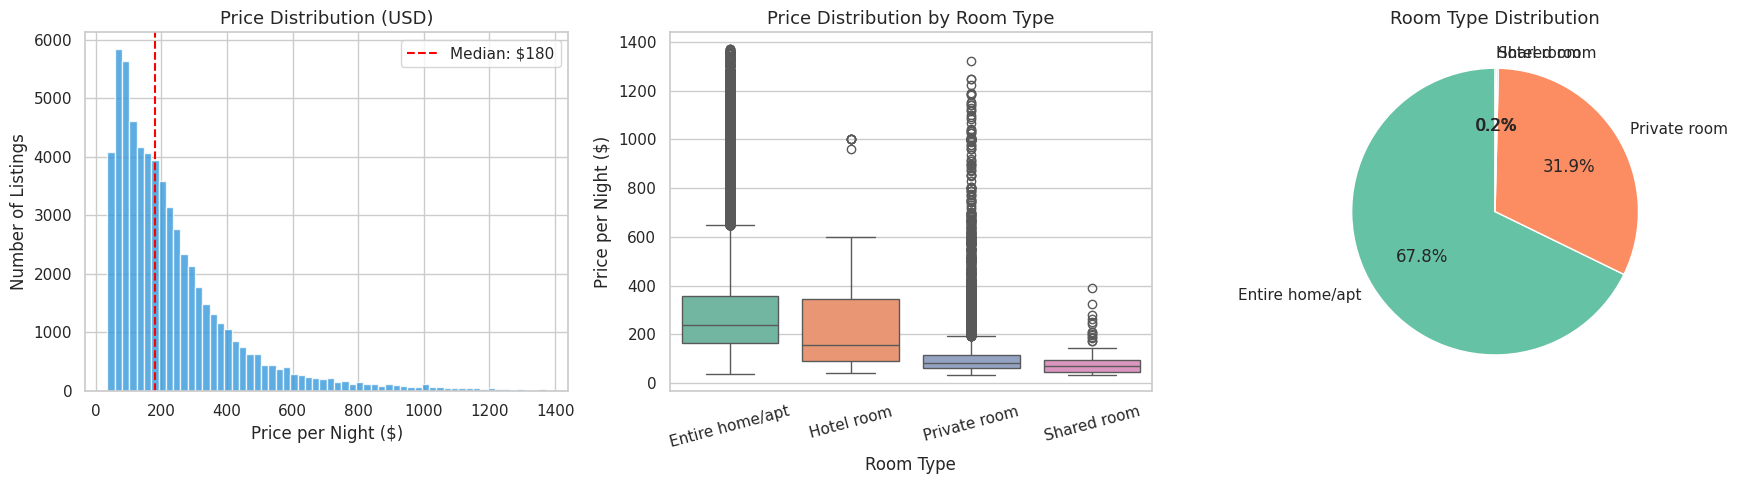

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Price distribution
axes[0].hist(analysis_main['price'], bins=60, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(analysis_main['price'].median(), color='red', linestyle='--', label=f"Median: ${analysis_main['price'].median():.0f}")
axes[0].set_title('Price Distribution (USD)', fontsize=13)
axes[0].set_xlabel('Price per Night ($)')
axes[0].set_ylabel('Number of Listings')
axes[0].legend()

# 2. Price by room type (boxplot)
room_order = analysis_main.groupby('room_type')['price'].median().sort_values(ascending=False).index.tolist()
sns.boxplot(data=analysis_main, x='room_type', y='price', ax=axes[1],
            palette='Set2', order=room_order)
axes[1].set_title('Price Distribution by Room Type', fontsize=13)
axes[1].set_xlabel('Room Type')
axes[1].set_ylabel('Price per Night ($)')
axes[1].tick_params(axis='x', rotation=15)

# 3. Room type pie chart
room_counts = analysis_main['room_type'].value_counts()
axes[2].pie(room_counts.values, labels=room_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2'), startangle=90)
axes[2].set_title('Room Type Distribution', fontsize=13)

plt.tight_layout()
plt.savefig(f'{IMAGE_PATH}/01_price_and_room_type.png', dpi=160, bbox_inches='tight')
plt.show()

### 16 - Visualization - Price by Area

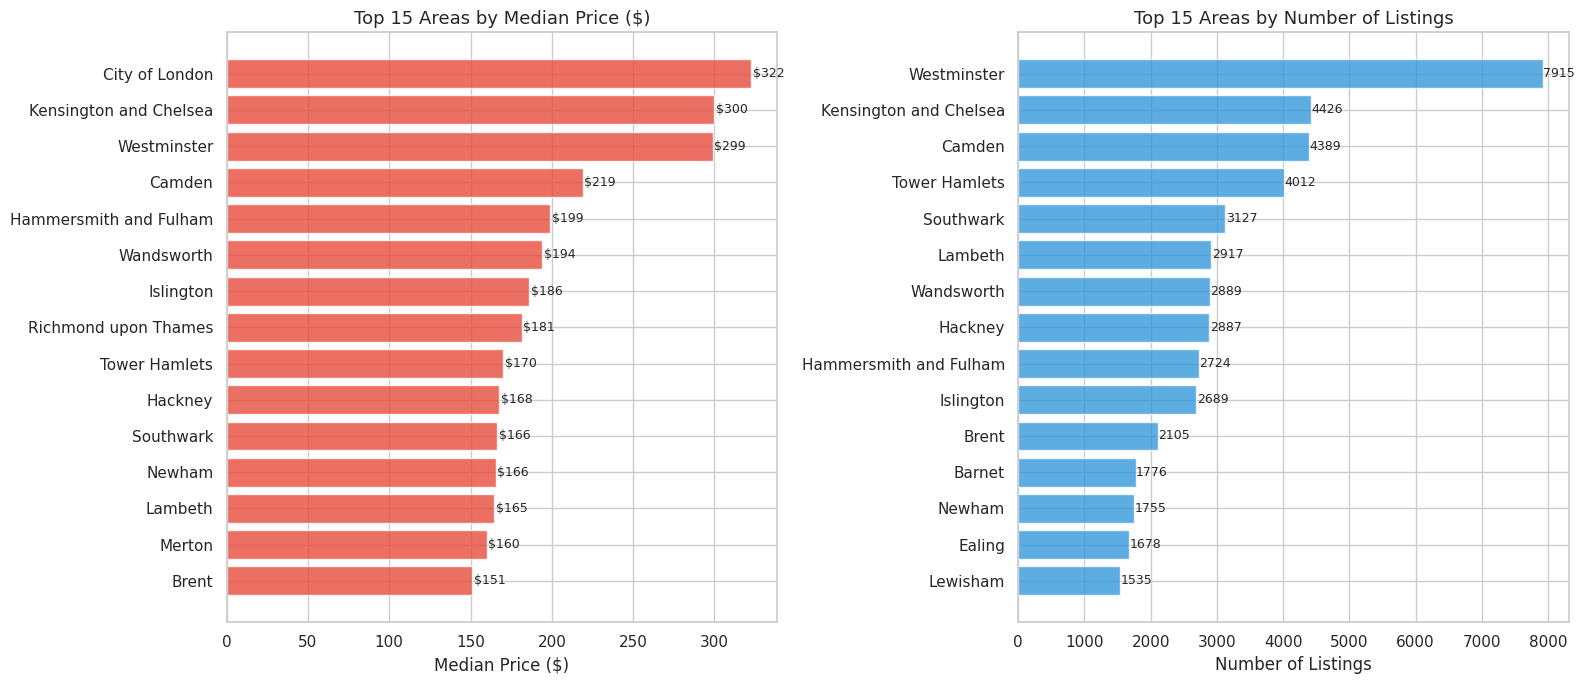

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Top 15 areas by median price (horizontal bar)
top_areas = area_summary.head(15).sort_values('median_price')
axes[0].barh(top_areas.index, top_areas['median_price'], color='#e74c3c', alpha=0.8)
axes[0].set_title('Top 15 Areas by Median Price ($)', fontsize=13)
axes[0].set_xlabel('Median Price ($)')

# Add value labels
for i, (area, row) in enumerate(top_areas.iterrows()):
    axes[0].text(row['median_price'] + 1, i, f"${row['median_price']:.0f}",
                 va='center', fontsize=9)

# 2. Top 15 areas by listing count
top_count = area_summary.sort_values('listings', ascending=False).head(15)
top_count_sorted = top_count.sort_values('listings')
axes[1].barh(top_count_sorted.index, top_count_sorted['listings'], color='#3498db', alpha=0.8)
axes[1].set_title('Top 15 Areas by Number of Listings', fontsize=13)
axes[1].set_xlabel('Number of Listings')

for i, (area, row) in enumerate(top_count_sorted.iterrows()):
    axes[1].text(row['listings'] + 5, i, f"{row['listings']:.0f}",
                 va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{IMAGE_PATH}/02_price_by_area.png', dpi=160, bbox_inches='tight')
plt.show()

### 17 - Visualization - Reviews & Availability

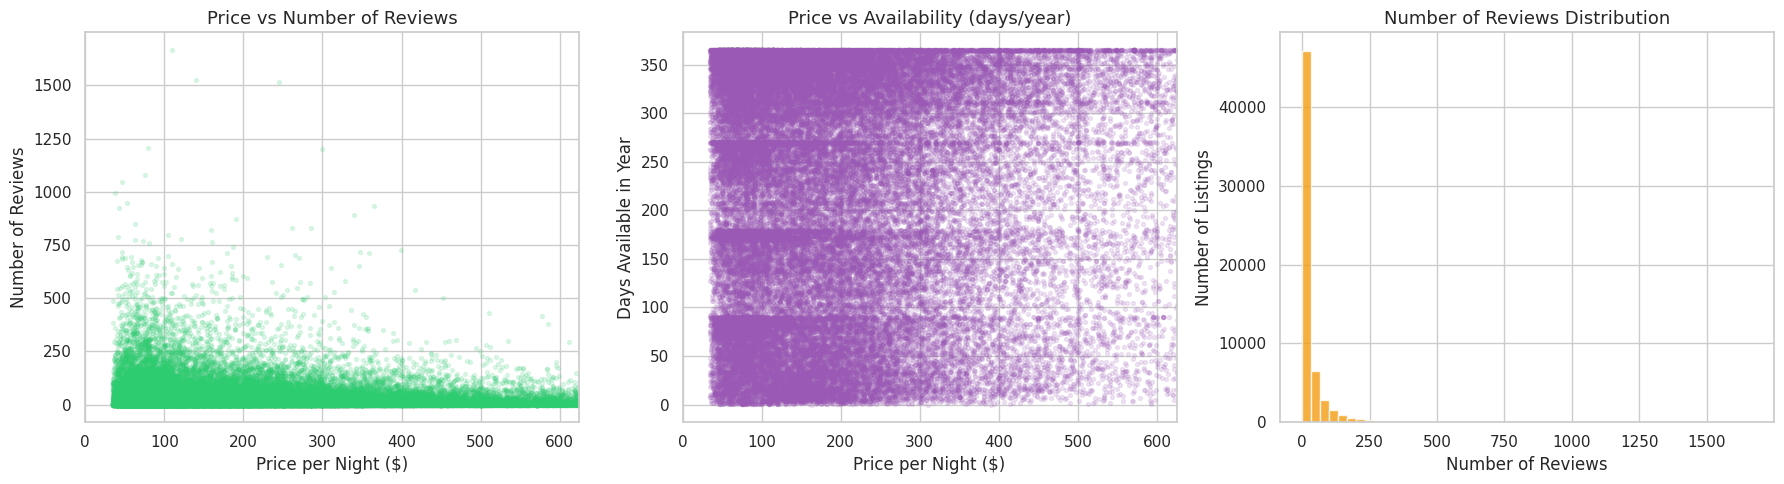

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Price vs Number of Reviews
axes[0].scatter(analysis_main['price'], analysis_main['number_of_reviews'],
                alpha=0.15, s=8, color='#2ecc71')
axes[0].set_title('Price vs Number of Reviews', fontsize=13)
axes[0].set_xlabel('Price per Night ($)')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_xlim(0, analysis_main['price'].quantile(0.95))

# 2. Price vs Availability
if 'availability_365' in analysis_main.columns:
    axes[1].scatter(analysis_main['price'], analysis_main['availability_365'],
                    alpha=0.15, s=8, color='#9b59b6')
    axes[1].set_title('Price vs Availability (days/year)', fontsize=13)
    axes[1].set_xlabel('Price per Night ($)')
    axes[1].set_ylabel('Days Available in Year')
    axes[1].set_xlim(0, analysis_main['price'].quantile(0.95))

# 3. Reviews distribution
axes[2].hist(analysis_main['number_of_reviews'], bins=50, color='#f39c12',
             edgecolor='white', alpha=0.8)
axes[2].set_title('Number of Reviews Distribution', fontsize=13)
axes[2].set_xlabel('Number of Reviews')
axes[2].set_ylabel('Number of Listings')

plt.tight_layout()
plt.savefig(f'{IMAGE_PATH}/03_reviews_and_availability.png', dpi=160, bbox_inches='tight')
plt.show()

### 18 - Visualization - Revenue Potential & Performance

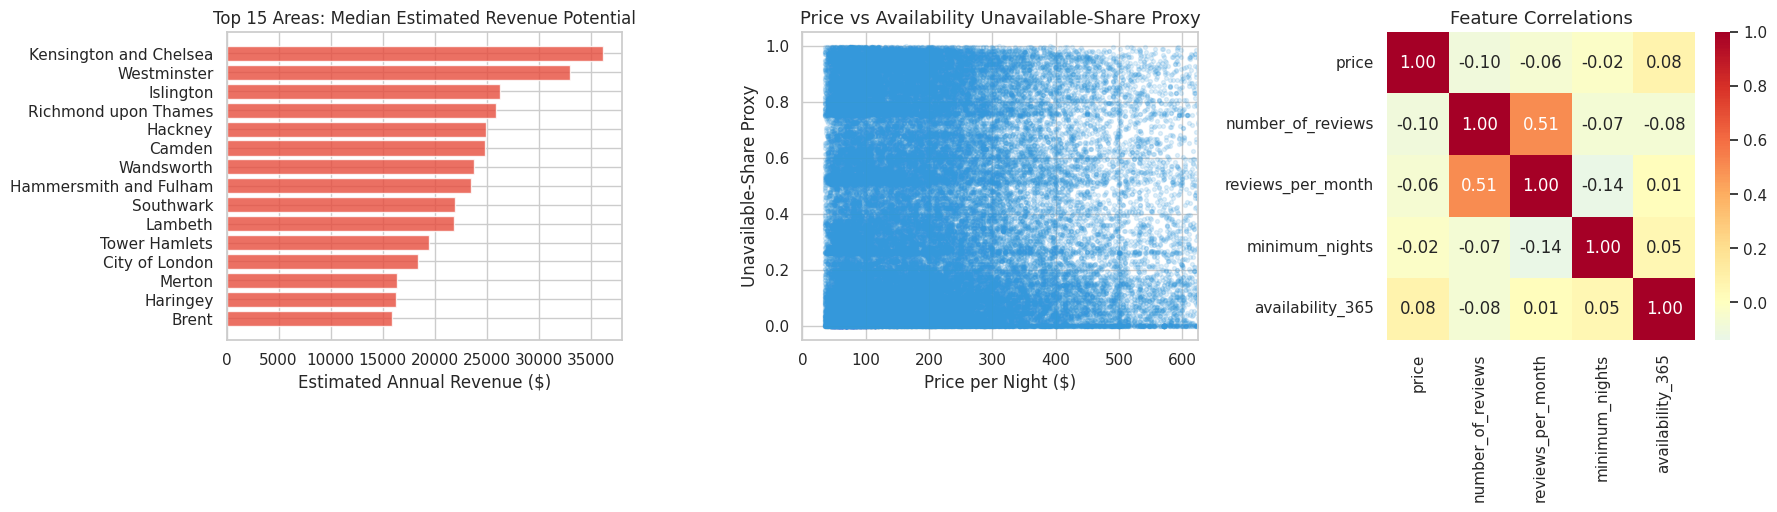

In [16]:
if 'estimated_revenue_potential_proxy' in analysis_main.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Revenue potential by area (top 15)
    revenue_by_area = (analysis_main.groupby(area_col)['estimated_revenue_potential_proxy']
                       .median().sort_values(ascending=False).head(15))
    revenue_by_area_sorted = revenue_by_area.sort_values()
    axes[0].barh(revenue_by_area_sorted.index, revenue_by_area_sorted.values,
                 color='#e74c3c', alpha=0.8)
    axes[0].set_title('Top 15 Areas: Median Estimated Revenue Potential', fontsize=12)
    axes[0].set_xlabel('Estimated Annual Revenue ($)')

    # 2. Price vs Occupancy Proxy
    if 'availability_unavailable_share_proxy' in analysis_main.columns:
      axes[1].scatter(
          analysis_main['price'],
          analysis_main['availability_unavailable_share_proxy'],
          alpha=0.15,
          s=8,
          color='#3498db'
      )
      axes[1].set_title(
          'Price vs Availability Unavailable-Share Proxy',
          fontsize=13
      )
      axes[1].set_xlabel('Price per Night ($)')
      axes[1].set_ylabel('Unavailable-Share Proxy')
      axes[1].set_xlim(
          0,
          analysis_main['price'].quantile(0.95)
      )

    elif 'calendar_unavailable_share_proxy' in analysis_main.columns:
        axes[1].scatter(
            analysis_main['price'],
            analysis_main['calendar_unavailable_share_proxy'],
            alpha=0.15,
            s=8,
            color='#3498db'
        )
        axes[1].set_title(
            'Price vs Calendar Unavailable-Share Proxy',
            fontsize=13
        )
        axes[1].set_xlabel('Price per Night ($)')
        axes[1].set_ylabel('Calendar Unavailable-Share Proxy')
        axes[1].set_xlim(
            0,
            analysis_main['price'].quantile(0.95)
        )

    # 3. Correlation heatmap
    corr_cols = ['price', 'number_of_reviews', 'reviews_per_month',
                 'minimum_nights', 'availability_365']
    corr_available = [c for c in corr_cols if c in analysis_main.columns]
    corr = analysis_main[corr_available].corr()
    sns.heatmap(corr, annot=True, cmap='RdYlBu_r', center=0,
                ax=axes[2], fmt='.2f', square=True)
    axes[2].set_title('Feature Correlations', fontsize=13)

    plt.tight_layout()
    plt.savefig(f'{IMAGE_PATH}/04_revenue_and_performance.png', dpi=160, bbox_inches='tight')
    plt.show()

### 19 - Visualization - Median Price Heatmap by Area & Room Type

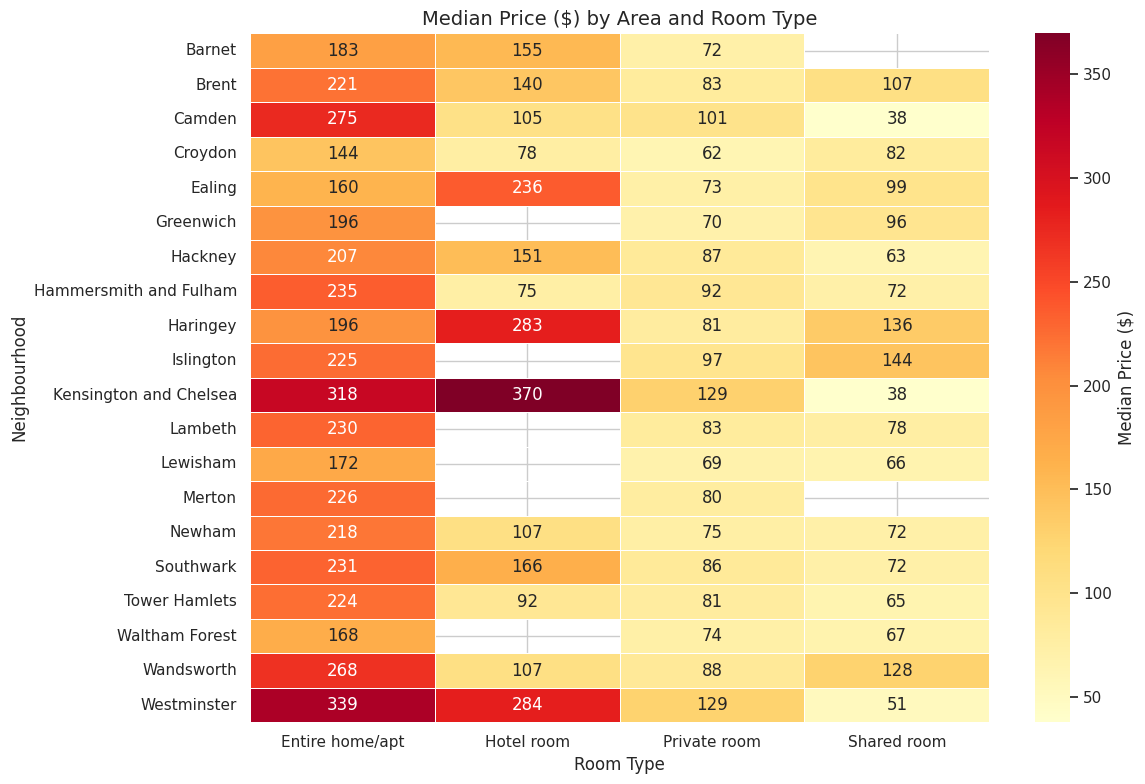

In [17]:
pivot = analysis_main.pivot_table(
    values='price', index=area_col, columns='room_type',
    aggfunc='median'
)

# Top 20 areas by total listings
top_20_areas = (analysis_main[area_col].value_counts()
                .head(20).index.tolist())
pivot_top = pivot.loc[pivot.index.isin(top_20_areas)]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot_top, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Median Price ($)'})
ax.set_title('Median Price ($) by Area and Room Type', fontsize=14)
ax.set_xlabel('Room Type')
ax.set_ylabel('Neighbourhood')

plt.tight_layout()
plt.savefig(f'{IMAGE_PATH}/05_price_heatmap.png', dpi=160, bbox_inches='tight')
plt.show()

### 20 - Visualization - Geographic Map

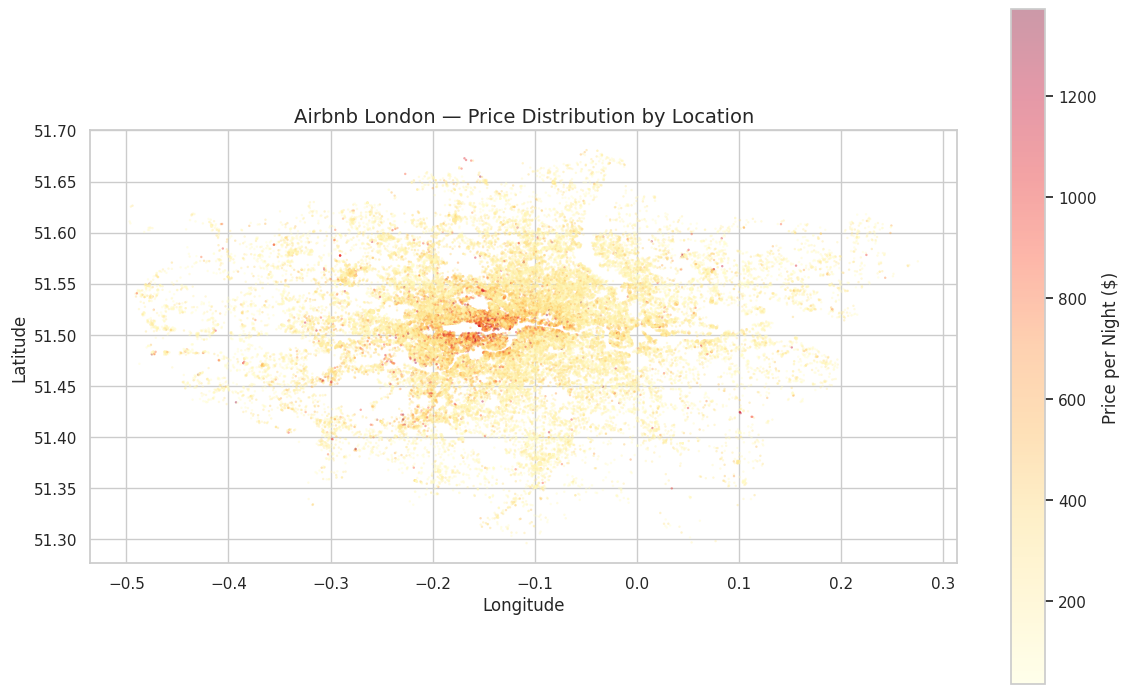

In [18]:
if 'latitude' in analysis_main.columns and 'longitude' in analysis_main.columns:
    fig, ax = plt.subplots(figsize=(12, 10))

    scatter = ax.scatter(
        analysis_main['longitude'], analysis_main['latitude'],
        c=analysis_main['price'], cmap='YlOrRd',
        s=3, alpha=0.4, edgecolors='none'
    )

    plt.colorbar(scatter, label='Price per Night ($)', shrink=0.7)
    ax.set_title('Airbnb London — Price Distribution by Location', fontsize=14)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_aspect('equal')

    plt.tight_layout()
    plt.savefig(f'{IMAGE_PATH}/06_geo_map.png', dpi=160, bbox_inches='tight')
    plt.show()

#### SQL Queries

In [19]:
!pip -q install duckdb
import duckdb

con = duckdb.connect()
con.register('listings', analysis_main)

# Query 1: Price by area (using neighbourhood_cleansed)
sql_price_area = con.sql('''
    SELECT neighbourhood_cleansed,
           COUNT(*) AS total_listings,
           MEDIAN(price) AS median_price_usd,
           ROUND(AVG(price), 2) AS average_price_usd,
           ROUND(AVG(number_of_reviews), 1) AS avg_reviews
    FROM listings
    WHERE price > 0
    GROUP BY neighbourhood_cleansed
    HAVING COUNT(*) >= 30
    ORDER BY median_price_usd DESC
    LIMIT 15
''').df()
print('=== Top 15 Areas by Median Price (SQL) ===')
print(sql_price_area)

# Query 2: Performance by room type
sql_room = con.sql('''
    SELECT room_type,
           COUNT(*) AS listings,
           MEDIAN(price) AS median_price_usd,
           ROUND(AVG(price), 2) AS average_price_usd,
           ROUND(AVG(number_of_reviews), 1) AS avg_reviews,
           ROUND(AVG(availability_365), 1) AS avg_availability_days
    FROM listings
    WHERE price > 0
    GROUP BY room_type
    ORDER BY median_price_usd DESC
''').df()
print('\n=== Performance by Room Type (SQL) ===')
print(sql_room)

# Query 3: Revenue potential by area
if 'estimated_revenue_potential_proxy' in analysis_main.columns:
    sql_revenue = con.sql('''
        SELECT neighbourhood_cleansed,
               COUNT(*) AS listings,
               MEDIAN(price) AS median_price_usd,
               MEDIAN(estimated_revenue_potential_proxy)
                   AS median_revenue_potential_proxy_usd
        FROM listings
        WHERE price > 0
        GROUP BY neighbourhood_cleansed
        HAVING COUNT(*) >= 30
        ORDER BY median_revenue_potential_proxy_usd DESC
        LIMIT 15
    ''').df()

    print('\n=== Top 15 Areas by Revenue Potential Proxy (SQL) ===')
    print(sql_revenue)

# Query 4: Calendar-based occupancy summary by area
if 'calendar_unavailable_share_proxy' in analysis_main.columns:
    sql_calendar = con.sql('''
        SELECT neighbourhood_cleansed,
               COUNT(*) AS listings,
               ROUND(
                   AVG(calendar_unavailable_share_proxy),
                   3
               ) AS avg_calendar_unavailable_share_proxy,
               ROUND(AVG(cal_days_available), 1)
                   AS avg_days_available
        FROM listings
        GROUP BY neighbourhood_cleansed
        HAVING COUNT(*) >= 30
        ORDER BY avg_calendar_unavailable_share_proxy DESC
        LIMIT 15
    ''').df()

    print(
        '\n=== Top 15 Areas by Calendar '
        'Unavailable-Share Proxy (SQL) ==='
    )
    print(sql_calendar)

# Query 5: Listings with most reviews
sql_top_reviews = con.sql('''
    SELECT name, neighbourhood_cleansed, room_type, price,
           number_of_reviews, reviews_per_month
    FROM listings
    WHERE number_of_reviews > 0
    ORDER BY number_of_reviews DESC
    LIMIT 10
''').df()
print('\n=== Top 10 Most Reviewed Listings (SQL) ===')
print(sql_top_reviews)

=== Top 15 Areas by Median Price (SQL) ===
    neighbourhood_cleansed  total_listings  median_price_usd  \
0           City of London             451            322.40   
1   Kensington and Chelsea            4426            300.00   
2              Westminster            7915            299.00   
3                   Camden            4389            219.00   
4   Hammersmith and Fulham            2724            199.10   
5               Wandsworth            2889            194.00   
6                Islington            2689            186.00   
7     Richmond upon Thames             803            181.38   
8            Tower Hamlets            4012            170.00   
9                  Hackney            2887            167.50   
10               Southwark            3127            166.50   
11                  Newham            1755            165.50   
12                 Lambeth            2917            164.60   
13                  Merton            1079            160.00 

## Key Findings

Based on the analysis above:

1. Median price across the analyzed London listings was USD 180 per night.

2. The highest median prices were observed in City of London (USD 322.40),
   Kensington and Chelsea (USD 300.00), Westminster (USD 299.00),
   Camden (USD 219.00), and Hammersmith and Fulham (USD 199.10).

3. Among areas with at least 30 listings, the lowest median prices were
   observed in Sutton (USD 86.70), Bexley (USD 99.07), Hillingdon (USD 101.00),
   Barking and Dagenham (USD 101.67), and Croydon (USD 103.00).

4. Entire home/apt listings had a median price of USD 238, compared with USD 83
   for private rooms. This is approximately a 186.7% higher median price,
   not a causal premium estimate.

5. The average calendar unavailable-share proxy was approximately 41.1%.
   This metric reflects calendar unavailability and is not confirmed
   occupancy or confirmed bookings.

6. Kensington and Chelsea and Westminster had the highest median revenue
   potential proxy among the areas shown in the SQL output. These values
   are scenario estimates, not actual host revenue.

7. The analysis is descriptive and cross-sectional. Relationships between
   price, reviews, and availability should not be interpreted as causal.

## Business Recommendation

1. For hosts, premium areas such as Kensington and Chelsea and Westminster
   support higher observed nightly prices, but pricing decisions should
   also consider competition, room type, and calendar availability.

2. For value-oriented guests, Sutton, Bexley, Hillingdon, Croydon, and
   Barking and Dagenham show lower median nightly prices among areas with
   at least 30 listings. Lower price should not automatically be interpreted
   as better value or higher quality.

3. Hackney, Islington, Richmond upon Thames, and Lambeth show relatively
   high calendar unavailable-share proxies. Hosts may investigate whether
   this reflects demand, blocked dates, or listing-management behavior.

4. Revenue potential should be used for scenario comparison only. It should
   not be presented as actual revenue because unavailable calendar dates
   are not confirmed bookings.

5. The analysis uses a single snapshot and describes associations rather
   than causal relationships.

### Save Summary Table

In [20]:
# Save summary tables for dashboard
# Cell 25 can be run independently after analysis_main has been created.
# Recreate room_analysis here if Cell 14 was skipped or the runtime was restarted.
if 'room_analysis' not in globals():
    room_analysis = (
        analysis_main.groupby('room_type')
        .agg(
            listings=('id', 'count'),
            median_price=('price', 'median'),
            average_price=('price', 'mean'),
            average_reviews=('number_of_reviews', 'mean'),
            average_min_nights=('minimum_nights', 'mean')
        )
        .sort_values('median_price', ascending=False)
    )

area_summary.to_csv(f'{PROCESSED_PATH}/area_summary.csv')
room_analysis.to_csv(f'{PROCESSED_PATH}/room_summary.csv')

if 'estimated_revenue_potential_proxy' in analysis_main.columns:
    revenue_summary = (
        analysis_main.groupby(area_col)
        .agg(
            listings=('id', 'count'),
            median_price_usd=('price', 'median'),
            median_revenue_potential_proxy_usd=(
                'estimated_revenue_potential_proxy',
                'median'
            )
        )
        .query('listings >= 30')
        .sort_values(
            'median_revenue_potential_proxy_usd',
            ascending=False
        )
    )

    revenue_summary.to_csv(
        f'{PROCESSED_PATH}/revenue_summary.csv'
    )

# Platform estimate summary (if available)
if 'estimated_revenue_l365d' in analysis_main.columns:
    platform_agg = {
        'listings': ('id', 'count'),
        'median_price': ('price', 'median'),
        'median_platform_revenue': ('estimated_revenue_l365d', 'median')
    }
    if 'estimated_occupancy_l365d' in analysis_main.columns:
        platform_agg['median_platform_occupied_nights'] = (
            'estimated_occupancy_l365d', 'median'
        )

    platform_revenue_summary = (
        analysis_main.groupby(area_col)
        .agg(**platform_agg)
        .query('listings >= 30')
        .sort_values('median_platform_revenue', ascending=False)
    )
    platform_revenue_summary.to_csv(
        f'{PROCESSED_PATH}/platform_revenue_summary.csv'
    )

# Calendar-based occupancy summary (if calendar.csv was merged)
if (
    'calendar_unavailable_share_proxy' in analysis_main.columns and
    'cal_days_available' in analysis_main.columns
):
    calendar_summary = (
        analysis_main.groupby(area_col)
        .agg(
            listings=('id', 'count'),
            avg_cal_days_available=(
                'cal_days_available',
                'mean'
            ),
            avg_calendar_unavailable_share_proxy=(
                'calendar_unavailable_share_proxy',
                'mean'
            )
        )
        .query('listings >= 30')
        .sort_values(
            'avg_calendar_unavailable_share_proxy',
            ascending=False
        )
    )

    calendar_summary.to_csv(
        f'{PROCESSED_PATH}/calendar_unavailability_summary.csv'
    )

print('All summary tables saved to Google Drive.')
print(f'Path: {PROCESSED_PATH}/')

All summary tables saved to Google Drive.
Path: /content/drive/MyDrive/Portfolio/airbnb-london-analysis/data/processed/


In [ ]:
# ==========================================
# Export File Khusus untuk Tableau
# ==========================================

# Pilih hanya kolom yang dibutuhkan untuk visualisasi
tableau_cols = [
    # Identitas
    'id',
    'name',

    # Lokasi
    'neighbourhood_cleansed',
    'latitude',
    'longitude',

    # Tipe properti
    'room_type',
    'property_type',
    'accommodates',
    'bedrooms',
    'beds',

    # Harga
    'price',

    # Ulasan
    'number_of_reviews',
    'reviews_per_month',
    'review_scores_rating',
    'review_count',

    # Ketersediaan
    'availability_365',
    'minimum_nights',

    # Metrik estimasi
    'estimated_occupancy_l365d',
    'estimated_occupancy_rate_l365d',
    'estimated_revenue_l365d',
    'estimated_revenue_potential_proxy',
    'estimated_occupied_nights_l365d',

    # Proxy
    'calendar_unavailable_share_proxy',
    'availability_unavailable_share_proxy',
    'has_reviews'
]

# Ambil hanya kolom yang benar-benar ada di analysis_main
tableau_cols = [
    col for col in tableau_cols
    if col in analysis_main.columns
]

# Buat dataframe khusus Tableau
airbnb_tableau = analysis_main[tableau_cols].copy()

# Rename agar nama kolom lebih mudah di Tableau
rename_map = {
    'id': 'listing_id',
    'neighbourhood_cleansed': 'neighbourhood',
    'number_of_reviews': 'total_reviews',
    'availability_365': 'available_days',
    'estimated_occupancy_l365d': 'est_occupied_nights',
    'estimated_occupancy_rate_l365d': 'est_occupancy_rate',
    'estimated_revenue_l365d': 'est_platform_revenue',
    'estimated_revenue_potential_proxy': 'revenue_potential_proxy',
    'estimated_occupied_nights_l365d': 'est_occupied_nights_alt',
    'availability_unavailable_share_proxy': 'avail_unavailable_share',
    'minimum_nights': 'min_nights',
    'review_scores_rating': 'review_rating',
    'review_count': 'calendar_review_count'
}

airbnb_tableau = airbnb_tableau.rename(columns=rename_map)

# Pastikan price bersih dari simbol
airbnb_tableau['price'] = (
    airbnb_tableau['price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.replace('£', '', regex=False)
)

airbnb_tableau['price'] = pd.to_numeric(
    airbnb_tableau['price'],
    errors='coerce'
)

# Pastikan semua kolom numerik benar tipe datanya
force_numeric = [
    'listing_id', 'latitude', 'longitude',
    'accommodates', 'bedrooms', 'beds',
    'price', 'total_reviews', 'reviews_per_month',
    'review_rating', 'calendar_review_count',
    'available_days', 'min_nights',
    'est_occupied_nights', 'est_occupancy_rate',
    'est_platform_revenue', 'revenue_potential_proxy',
    'est_occupied_nights_alt',
    'calendar_unavailable_share_proxy',
    'avail_unavailable_share'
]

for col in force_numeric:
    if col in airbnb_tableau.columns:
        airbnb_tableau[col] = pd.to_numeric(
            airbnb_tableau[col],
            errors='coerce'
        )

# Simpan sebagai TSV
airbnb_tableau.to_csv(
    f'{PROCESSED_PATH}/airbnb_london_tableau.tsv',
    sep='\t',
    index=False,
    encoding='utf-8'
)

# Simpan juga versi CSV sebagai backup
airbnb_tableau.to_csv(
    f'{PROCESSED_PATH}/airbnb_london_tableau.csv',
    index=False,
    encoding='utf-8-sig'
)

print('=== File untuk Tableau ===')
print(f'Kolom: {airbnb_tableau.columns.tolist()}')
print(f'Jumlah kolom: {len(airbnb_tableau.columns)}')
print(f'Baris: {len(airbnb_tableau):,}')
print(f'\nTSV: {PROCESSED_PATH}/airbnb_london_tableau.tsv')
print(f'CSV: {PROCESSED_PATH}/airbnb_london_tableau.csv')
print(f'\nTipe data:')
print(airbnb_tableau.dtypes)

In [ ]:
check = pd.read_csv(
    f'{PROCESSED_PATH}/airbnb_london_tableau.tsv',
    sep='\t'
)

print('Kolom:', check.columns.tolist())
print('Shape:', check.shape)
print(check.head(2))
print('\nTipe data:')
print(check.dtypes)

In [ ]:
from google.colab import drive, files
drive.mount('/content/drive')

!zip -r /content/airbnb_london_export.zip \
  /content/drive/MyDrive/Portfolio/airbnb-london-analysis

In [ ]:
!ls -lh /content/airbnb_london_export.zip

In [ ]:
files.download('/content/airbnb_london_export.zip')